In [2]:
import os
import json
import sys
import numpy as np
import matplotlib.pyplot as plt

# Add scripts folder to path to allow importing inference_utils
# Assuming notebook is in fpga_results/ and scripts is in ../scripts/fpga
sys.path.append(os.path.abspath("../scripts/fpga"))

try:
    from inference_utils import visualize_patches

    print("Successfully imported visualize_patches from inference_utils")
except ImportError as e:
    print(f"Could not import inference_utils: {e}")
    # Fallback if needed, or define visualize_patches here inline

# --- CONFIGURATION ---
# Set the path to the folder you copied back from the FPGA
# Example: "results/inference_model_quant_2026-01-19_10-00-00"
RESULTS_DIR = "inference_ResidualScaleHyperpriorDPUWrapper_pt_20211223_161544"

if not os.path.exists(RESULTS_DIR):
    print(f"WARNING: Directory {RESULTS_DIR} does not exist. Please update the path.")
else:
    print(f"Analyzing results from: {RESULTS_DIR}")

Successfully imported visualize_patches from inference_utils
Analyzing results from: inference_ResidualScaleHyperpriorDPUWrapper_pt_20211223_161544


In [3]:
# 1. Print Execution Summary
metrics_path = os.path.join(RESULTS_DIR, "metrics.json")
log_path = os.path.join(RESULTS_DIR, "inference.log")

# Check Log Header for Model Info
if os.path.exists(log_path):
    print("\n--- Run Info ---")
    with open(log_path, "r") as f:
        # Print first 5 lines (Timestamp, Model, Data info)
        for i in range(5):
            line = f.readline()
            if not line:
                break
            print(line.strip())

# Print Metrics
if os.path.exists(metrics_path):
    with open(metrics_path, "r") as f:
        metrics = json.load(f)
    print("\n--- Final Metrics ---")
    print(json.dumps(metrics, indent=4))
else:
    print("\nmetrics.json not found in result directory.")


--- Run Info ---
Starting Hybrid Inference at 20211223_161544
Model: models/ResidualScaleHyperpriorDPUWrapper_pt/ResidualScaleHyperpriorDPUWrapper_pt.xmodel
Data: data/test_1000.npy
Subset: 20
Loading graph from models/ResidualScaleHyperpriorDPUWrapper_pt/ResidualScaleHyperpriorDPUWrapper_pt.xmodel...

--- Final Metrics ---
{
    "Noisy": {
        "bpp": 0.06867599892862807,
        "mse": 46213.944140625,
        "psnr": -45.959388500396145,
        "merlin": 217556.00859375
    },
    "ADAM": {
        "bpp": 0.06867599892862807,
        "mse": 40626.18515625,
        "psnr": -45.655587285076194,
        "merlin": 196475.925
    },
    "MERLIN": {
        "bpp": 0.06867599892862807,
        "mse": 46074.543359375,
        "psnr": -45.912882135625594,
        "merlin": 215784.74296875
    }
}


Loading reconstruction arrays...
Loaded 5 patches for visualization.
Figure saved to: inference_ResidualScaleHyperpriorDPUWrapper_pt_20211223_161544/recreated_visual_comparison.png


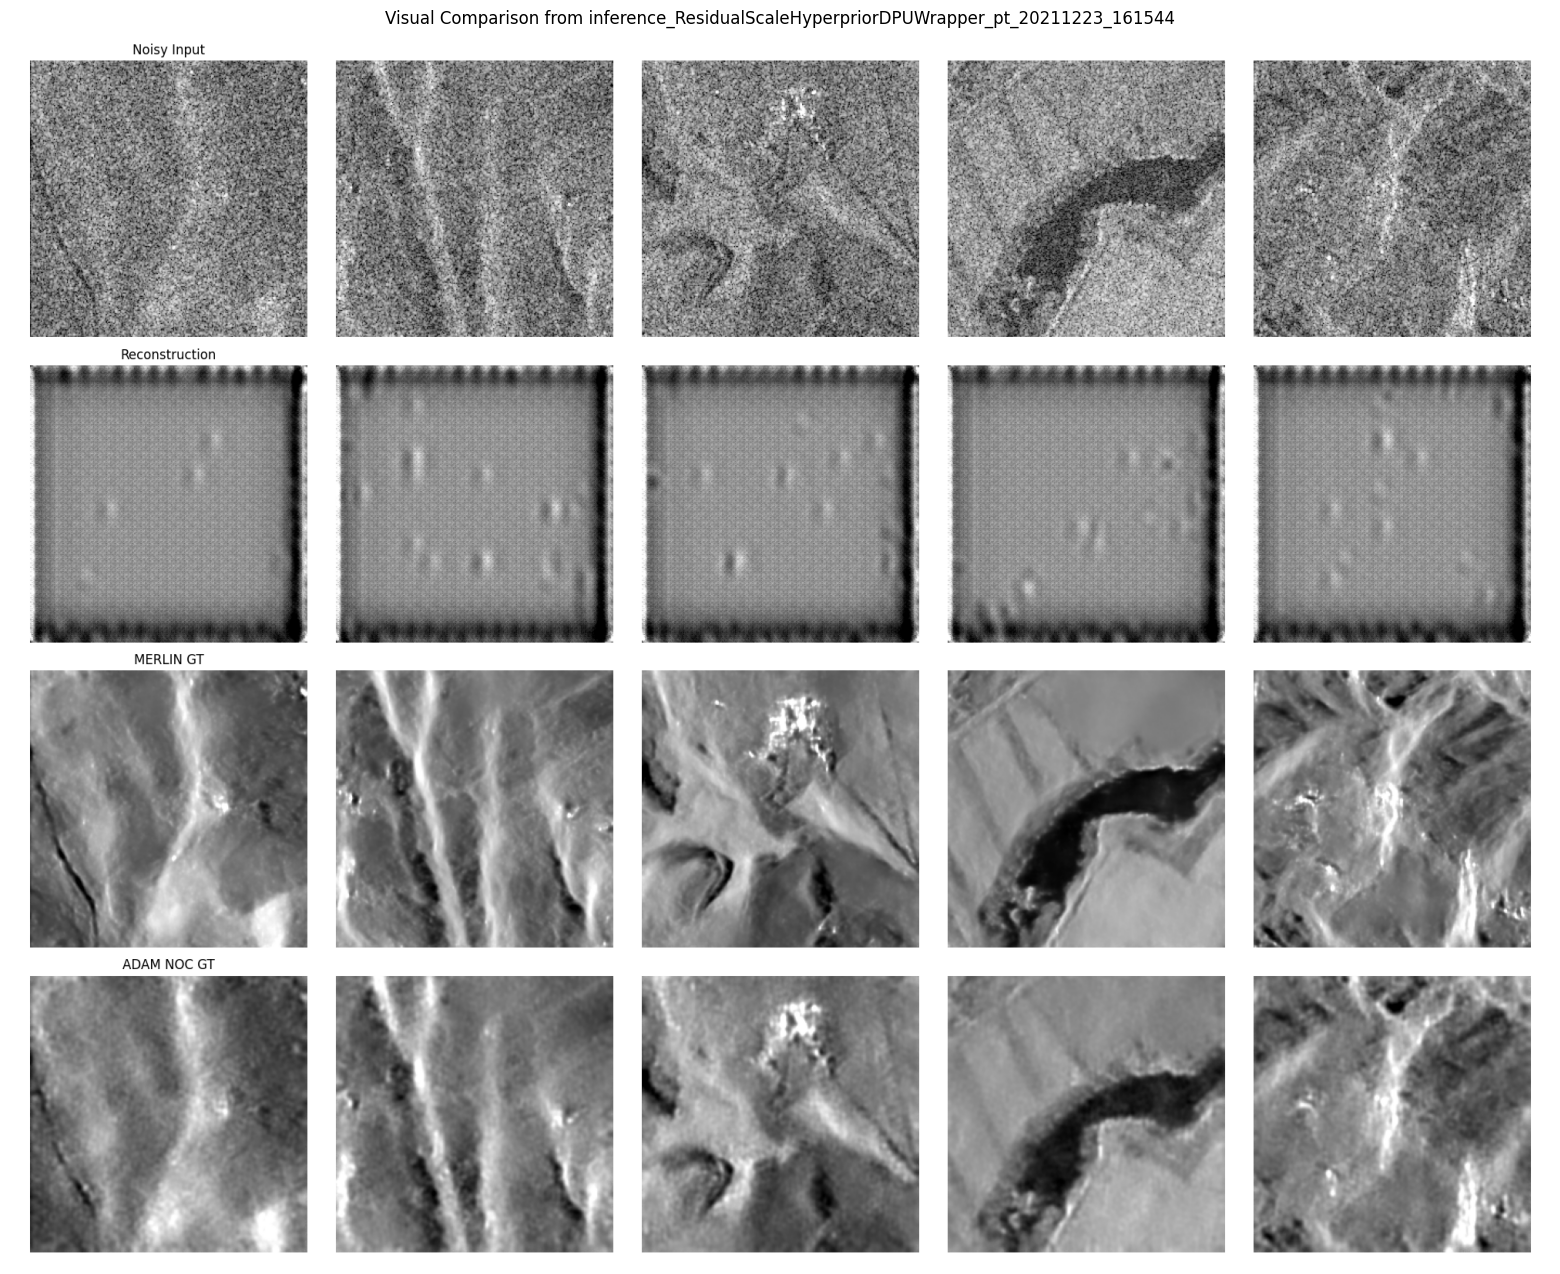

In [4]:
# 2. Reconstruct Visualization from Raw Arrays
recons_dir = os.path.join(RESULTS_DIR, "reconstructions")

if os.path.exists(recons_dir):
    print("Loading reconstruction arrays...")
    try:
        vis_noisy = np.load(os.path.join(recons_dir, "vis_noisy.npy"))
        vis_recon = np.load(os.path.join(recons_dir, "vis_recon.npy"))
        vis_adam = np.load(os.path.join(recons_dir, "vis_adam.npy"))
        vis_merlin = np.load(os.path.join(recons_dir, "vis_merlin.npy"))

        print(f"Loaded {len(vis_noisy)} patches for visualization.")

        save_path = os.path.join(RESULTS_DIR, "recreated_visual_comparison.png")

        # Generate Figure
        visualize_patches(vis_noisy, vis_recon, vis_adam, vis_merlin, save_path)
        print(f"Figure saved to: {save_path}")

        # Display inline
        img = plt.imread(save_path)
        plt.figure(figsize=(20, 16))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Visual Comparison from {RESULTS_DIR}")
        plt.show()

    except Exception as e:
        print(f"Error processing visualization: {e}")
        import traceback

        traceback.print_exc()
else:
    print(
        f"No 'reconstructions' folder found in {RESULTS_DIR}. Run inference with updated script to generate these."
    )